# Crop Recommendation

## Importing Libraries

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
RANDOM_STATE = 42

sns.set_theme(style = "whitegrid")
pd.set_option("display.max_column", None)

## Loading the dataset

In [105]:
df = pd.read_csv("/content/drive/MyDrive/NBICT LAB PDSML-B-8/11. Crop Recommendation/Crop_recommendation.csv")

## Data Inspection

In [106]:
# Checking the exact column name
print(df.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [107]:
# Auditing data quality
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


### Making Quality Report

In [108]:
Quality_Report = pd.DataFrame(
    {
       "missing_value": df.isna().sum(),
       "unique_values": df.nunique(),
       "data_type": df.dtypes,

    }
)

Quality_Report

,missing_value,unique_values,data_type
N,0,137,int64
P,0,117,int64
K,0,73,int64
temperature,0,2200,float64
humidity,0,2200,float64
ph,0,2200,float64
rainfall,0,2200,float64
label,0,22,object


### Checking Duplicates

In [109]:
print("Duplicate Row:", df.duplicated().sum())

Duplicate Row: 0


### Checking descriptive statistics

In [110]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


### Checking the target column

In [111]:
print("Number of crops:", df["label"].nunique())

Number of crops: 22


In [112]:
df["label"].value_counts().sort_index()

,count
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


### Visualizing Class balance

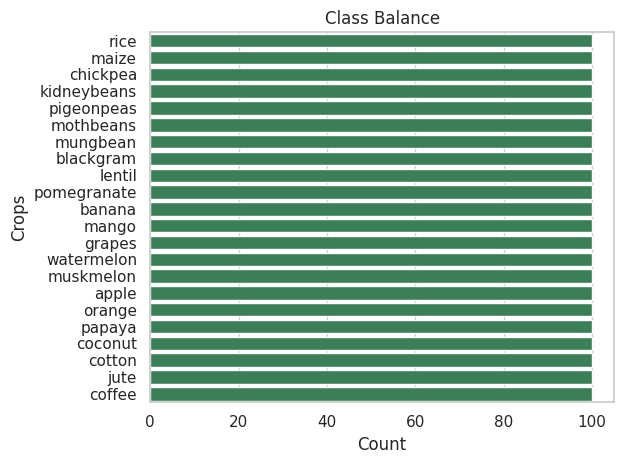

In [113]:
crops = df["label"].value_counts().index
sns.countplot(data = df, y = "label", order = crops, color = 'seagreen')
plt.title("Class Balance")
plt.xlabel("Count")
plt.ylabel("Crops")
plt.tight_layout()

plt.show()


### Calculating avarage condition by crops

In [114]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
crop_profile = df.groupby("label")[features].mean().round(2)
crop_profile

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.63,92.33,5.93,112.65
banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63
blackgram,40.02,67.47,19.24,29.97,65.12,7.13,67.88
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
coconut,21.98,16.93,30.59,27.41,94.84,5.98,175.69
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07
cotton,117.77,46.24,19.56,23.99,79.84,6.91,80.40
grapes,23.18,132.53,200.11,23.85,81.88,6.03,69.61
jute,78.40,46.86,39.99,24.96,79.64,6.73,174.79


### Looking at the crop with the highest mean requirement for each fertilizers

In [115]:
for feature in features:
  crop = crop_profile[feature].idxmax()
  value = crop_profile.loc[crop, feature]
  print(f'Highest avarage {feature}: {crop} ({value})')

Highest avarage N: cotton (117.77)
Highest avarage P: apple (134.22)
Highest avarage K: grapes (200.11)
Highest avarage temperature: papaya (33.72)
Highest avarage humidity: coconut (94.84)
Highest avarage ph: chickpea (7.34)
Highest avarage rainfall: rice (236.18)


**Question to answer before building a machine learning model**
1. How many rows and column are present?
2. Are there missing value?
3. Are there duplicate row?
4. How many crop classes are present?
5. Is the target is balance?
6. Do any features look physically suspicious?

For example, pH values should be checked carefully.

In [116]:
df['ph'].agg(['min', 'max'])

,ph
min,3.504752
max,9.935091


## Spliting the dataset into training set and test set

In [117]:
X = df.drop("label", axis = 1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y) # Stratify fix the ratio of the test set lebel

## Inspecting and Exporting the training set and test set

In [118]:
print(X_train)

       N    P    K  temperature   humidity        ph    rainfall
1607   0   18   14    29.771494  92.007200  7.207991  114.416179
1212   9  122  201    29.587484  80.919344  5.570291   68.064173
362   11   71   24    21.140114  22.718235  5.606620  141.605672
566   38   38   18    26.310518  61.187491  6.294130   35.734038
1671  18   12    8    12.590940  91.816688  6.206053  119.391672
...   ..  ...  ...          ...        ...       ...         ...
808   13   64   20    19.134577  62.575269  6.590571   36.469470
422   16   55   19    19.543141  47.191883  6.413544  192.437219
2052  82   48   36    25.793520  81.769040  6.352077  193.241838
2083  90   50   44    26.916437  73.486560  6.253409  171.471638
1282   1  132  200    16.278528  82.942701  5.620746   66.574628

[1760 rows x 7 columns]


In [119]:
print(y_train)

1607         orange
1212         grapes
362     kidneybeans
566       mothbeans
1671         orange
           ...     
808          lentil
422      pigeonpeas
2052           jute
2083           jute
1282         grapes
Name: label, Length: 1760, dtype: object


### Export the training set

In [120]:
training_set = pd.concat([X_train, y_train], axis = 1)
training_set.to_csv("training_set.csv", index = False)

### Exporting the test set

In [121]:
test_set = pd.concat([X_test, y_test], axis = 1)
test_set.to_csv("test_set.csv", index = False)

## Training the decision tree classification model

In [122]:
from sklearn.tree import DecisionTreeClassifier

In [123]:
dt_model = DecisionTreeClassifier(random_state = RANDOM_STATE)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Predicting the test set result

In [124]:
y_pred_dt = dt_model.predict(X_test)

In [125]:
test_set["predicted_label"] = y_pred_dt
test_set.to_csv("test_set_with_pred.csv", index = False)

## Decision tree evaluation

In [126]:
labels = sorted(y.unique())
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 16  0  0  0  0  0  0  0  2  1  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 18  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0 19  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

In [127]:
cm_dt_df = pd.DataFrame(
    cm_dt,
    index=labels,
    columns=labels
)

cm_dt_df

,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,lentil,maize,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
apple,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
banana,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blackgram,0,0,16,0,0,0,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,0
chickpea,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
coconut,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
coffee,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
cotton,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
grapes,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0
jute,0,0,0,0,0,0,0,0,19,0,0,0,0,0,0,0,0,0,0,0,1,0
kidneybeans,0,0,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0


## Accuracy Score

In [128]:
as_dt = accuracy_score(y_test, y_pred_dt)
as_dt

0.9795454545454545

## Examining the classification report

In [129]:
from sklearn.metrics import classification_report
cr_dt = classification_report(y_test, y_pred_dt, zero_division=0)
print(cr_dt)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.80      0.89        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.86      0.90      0.88        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

## Training the Random Forest classification model

In [130]:
# Importing the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [131]:
# Building the Random Forest Classifier Model
rf_model = RandomForestClassifier(n_estimators=300, n_jobs= -1,random_state = RANDOM_STATE)

# Training the Random Forest Classifier Model
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

### Evaluation

In [132]:
# Predecting the test set result
y_pred_rf = rf_model.predict(X_test)

# Making the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

In [133]:
# Converting the confusion matrix to a dataform
cm_rf_df = pd.DataFrame(
    cm_rf,
    index=labels,
    columns=labels
)

cm_rf_df

,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,lentil,maize,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
apple,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
banana,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blackgram,0,0,19,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
chickpea,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
coconut,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
coffee,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
cotton,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
grapes,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0
jute,0,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0
kidneybeans,0,0,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0


In [134]:
# Calculating the accuracy score for the random forest model
as_rf = accuracy_score(y_test, y_pred_rf)
as_rf

0.9931818181818182

In [135]:
# Building the classsification report for the Random Forest Model
cr_rf = classification_report(y_test, y_pred_rf, zero_division=0)
print(cr_rf)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

## **Making one crop recommendation**

In [136]:
# The feature order must match the training order
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

In [137]:
# Creating a one-row DataFrame
new_conditions = pd.DataFrame({
    "N": [90],
    "P": [42],
    "K": [43],
    "temperature": [20],
    "humidity": [80],
    "ph": [6.5],
    "rainfall": [200]
})
new_conditions

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20,80,6.5,200


In [138]:
# Predicting the crop
recommended_crop = rf_model.predict(new_conditions)[0]
print("Recommended crop:", recommended_crop)

Recommended crop: rice


###  **Returning the top three recommendations**

In [139]:
# Calculating the probability values
probabilities = rf_model.predict_proba(new_conditions)[0]
print(probabilities)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.13333333 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.00333333 0.86       0.00333333]


In [140]:
# Sorting the indices
sorted_indices = probabilities.argsort()
print(sorted_indices)

[ 0  1  2  3  4  5  6  7  9 10 11 12 14 13 15 16 18 17 21 19  8 20]


In [141]:
# Reverse sorting
rev_sorted_indices = sorted_indices[::-1]
print(rev_sorted_indices)

[20  8 19 21 17 18 16 15 13 14 12 11 10  9  7  6  5  4  3  2  1  0]


In [142]:
# Printing the top 3 indices
top_indices = rev_sorted_indices[:3]
print(top_indices)

[20  8 19]


In [143]:
# Printing the top 3 recommendations
top_recommendations = pd.DataFrame({
    "Crop": rf_model.classes_[top_indices],
    "Model probability": probabilities[top_indices]
})
top_recommendations

,Crop,Model probability
0,rice,0.860000
1,jute,0.133333
2,pomegranate,0.003333


## Making Predictions for a csv file

In [145]:
new_data = pd.read_csv("/content/drive/MyDrive/NBICT LAB PDSML-B-8/11. Crop Recommendation/recommend_crop.csv")
print(new_data)

     N   P   K  temperature   humidity        ph    rainfall
0   13  23   6    23.961476  90.264080  7.365338  102.695870
1   98  79  50    25.341198  84.473213  6.435917   91.064934
2  140  38  15    24.147295  75.882986  6.021440   69.915635
3   71  54  16    22.613600  63.690706  5.749914   87.759539
4   40  22   6    24.536101  91.909972  6.488221  115.978799
5   25  68  77    20.093406  15.112796  7.701446   85.749049
6   60  49  44    20.775761  84.497744  6.244841  240.081065
7   25  62  21    26.734340  68.139997  7.040056   67.150964
8  110  71  54    28.672089  82.207936  5.725419   94.379875
9   10   5   5    21.213070  91.353492  7.817846  112.983436


In [151]:
new_data['best_crop'] = rf_model.predict(new_data)

In [152]:
print(new_data)

     N   P   K  temperature   humidity        ph    rainfall  best_crop
0   13  23   6    23.961476  90.264080  7.365338  102.695870     orange
1   98  79  50    25.341198  84.473213  6.435917   91.064934     banana
2  140  38  15    24.147295  75.882986  6.021440   69.915635     cotton
3   71  54  16    22.613600  63.690706  5.749914   87.759539      maize
4   40  22   6    24.536101  91.909972  6.488221  115.978799     orange
5   25  68  77    20.093406  15.112796  7.701446   85.749049   chickpea
6   60  49  44    20.775761  84.497744  6.244841  240.081065       rice
7   25  62  21    26.734340  68.139997  7.040056   67.150964  blackgram
8  110  71  54    28.672089  82.207936  5.725419   94.379875     banana
9   10   5   5    21.213070  91.353492  7.817846  112.983436     orange
